In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path=(r"C:\Users\ICT047\Desktop\python\Health_dataset.csv")
df=pd.read_csv(file_path)

# 1 Total no of patients 

In [3]:
Total_Patients=df.shape[0]
print(Total_Patients)

8000


# 2 How is the patiens population distributed by gender

In [4]:
gender_distribution =df['Gender'].value_counts().reset_index(name='total')
print(gender_distribution)

   Gender  total
0    Male   5206
1  Female   2794


# visualixing it 

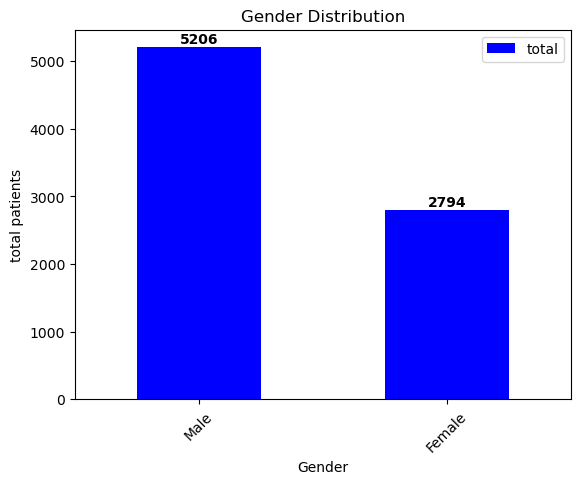

In [46]:
ax=gender_distribution.plot(kind="bar",color=['blue','red'])
ax.bar_label(ax.containers[0], padding=1, fontsize=10, fontweight='bold')
plt.xticks(range(len(gender_distribution)),gender_distribution['Gender'],rotation=45)
plt.title('Gender Distribution')
plt.ylabel('total patients')
plt.xlabel('Gender')
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient ID        8000 non-null   object
 1   Gender            8000 non-null   object
 2   Disease           8000 non-null   object
 3   Treatment         8000 non-null   object
 4   Hospital          8000 non-null   object
 5   Admission Date    8000 non-null   object
 6   Discharge Date    8000 non-null   object
 7   Treatment Status  8000 non-null   object
 8   Cause of Death    419 non-null    object
 9   Date of Birth     8000 non-null   object
dtypes: object(10)
memory usage: 625.1+ KB


# 3 Patients age group by total visit 

#convert both Admission Date and Discharge Date to proper date format

In [7]:
df['Admission Date']=pd.to_datetime(df['Admission Date'])
df['Date of Birth']=pd.to_datetime(df['Date of Birth'])
df['Discharge Date']=pd.to_datetime(df['Discharge Date'])

#creating a new age column

In [8]:
df['Age']=(df['Admission Date']-df['Date of Birth']).dt.days/365.25
df['Age']=df['Age'].astype(int)

#creating bins and labels for the age group

In [9]:
bins=[0,10,40,60,80,100]
labels=['0-20','21-40','41-60','61-80','81-100']

#creating new age group colums

In [10]:
df['Age Group']=pd.cut(df['Age'],bins=bins,labels=labels, right=False)

#Age group of patients

In [39]:
Age_group_distribution=df['Age Group'].value_counts().reset_index(name='Total Cases')
Age_group_distribution

,Age Group,Total Cases
0,21-40,2420
1,41-60,1608
2,81-100,1603
3,61-80,1580
4,0-20,759


# visualizing the age group

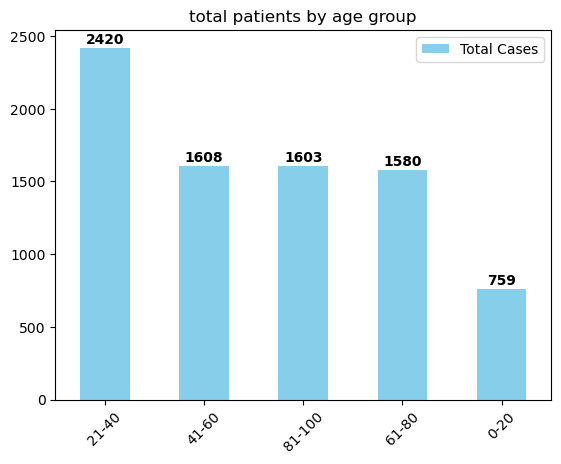

In [42]:
ax=Age_group_distribution.plot(kind='bar',color='skyblue')
ax.bar_label(ax.containers[0], padding=1, fontsize=10, fontweight='bold')
plt.xticks(range(len(Age_group_distribution)), Age_group_distribution['Age Group'], rotation=45)
plt.title('total patients by age group')
plt.show()

# 4 which disease are most commomly diagnosed among the patients 

In [14]:
top3_disease=df['Disease'].value_counts().nlargest(3).reset_index(name='Total Cases')
top3_disease

,Disease,Total Cases
0,Malaria,1193
1,Asthma,966
2,Tuberculosis,864


#total cases of top3 disease

In [15]:
top3_disease_count=int(top3_disease['Total Cases'].sum())
print(f"total case of top 3 diagnosis are {top3_disease_count:,}")

total case of top 3 diagnosis are 3,023


# to make it dynamic

In [16]:
dynamic=6
top3_disease=df['Disease'].value_counts().nlargest(dynamic).reset_index(name='Total Cases')
top3_disease_count=int(top3_disease['Total Cases'].sum())
description=f"total count of top {dynamic} disease"
print(description ,f"{top3_disease_count:,}")

total count of top 6 disease 5,088


# 5 percentage of top3 disease in all diagnosis

In [17]:
#count of top3 disease
top3_disease=df['Disease'].value_counts().nlargest(3)
#count of total diagnosis
total_disease_count=df['Disease'].value_counts().sum()

#percentage of top3 disease in total disease diagnosis
percentage=(top3_disease/total_disease_count)*100

#rounding up the value to zero and setting type as integer
roundpct=percentage.round().astype(int)

for disease, pct in roundpct.items():
    print(f"{disease} :{pct}%")


Malaria :15%
Asthma :12%
Tuberculosis :11%


# visualizing in a pie chart

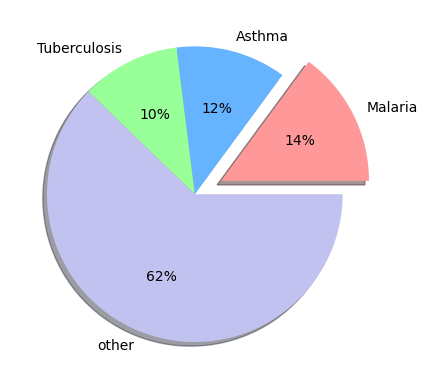

In [18]:
#calculating the number of total other diagnosis
other_disease=int(total_disease_count-top3_disease.sum())

labels=list(top3_disease.index)+['other']
size=list(top3_disease.values)+[other_disease]
# Creating the Pie Chart
plt.pie(size,labels=labels,autopct='%1d%%',
       colors=['#ff9999','#66b3ff','#99ff99','#c2c2f0'],
       explode=(0.2, 0, 0,0),
       shadow=True)
plt.show()


# 6 percentage of each top disease in over all counts of top3 disease

In [19]:
#count of top3 disease
top3_disease=df['Disease'].value_counts().nlargest(3)

#sum of total top 3 diagnosis
total_top3_disease_count=top3_disease.sum()

#percentage of each top3 disease in total top3 disease diagnosis
percentage=(top3_disease/total_top3_disease_count)*100

#rounding up the value to zero and setting type as integer
roundpct=percentage.round().astype(int)


for disease, pct in roundpct.items():
    print(f"{disease} :{pct}%")

Malaria :39%
Asthma :32%
Tuberculosis :29%


# visualizing in a pie chart

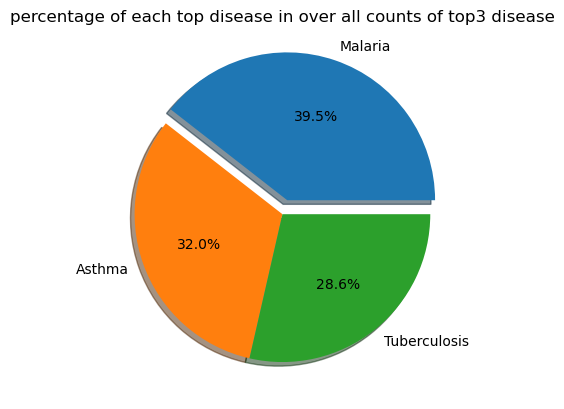

In [20]:
#assigning the size and label
labels=list(top3_disease.index)
size=list(top3_disease.values)

#constructing the pie chart
plt.pie(size,labels=labels,autopct='%1.1f%%',
       shadow=True,
       explode=(0.1,0,0),
    )
plt.title('percentage of each top disease in over all counts of top3 disease')
plt.show()



# 7 Are certain disease  more prevalent on one gender compare to the other 

In [21]:
gender_disease=pd.crosstab(df['Disease'],df['Gender']).reset_index()
gender_disease

Gender,Disease,Female,Male
0,Asthma,320,646
1,COVID-19,53,104
2,Cancer,239,452
3,Dengue,27,42
4,Diabetes,256,438
5,HIV/AIDS,155,333
6,Heart Disease,206,361
7,Hypertension,65,108
8,Kidney Failure,182,293
9,Liver Disease,73,171


# 8 calculate the duration of each patient and create a group to shownumber of patient in each group

In [22]:
# creating a stay duration column
df['Stay Duration']=(df['Discharge Date']-df['Admission Date']).dt.days
print(df[['Admission Date','Discharge Date','Stay Duration']])

     Admission Date Discharge Date  Stay Duration
0        2022-12-19     2023-01-16             28
1        2023-03-29     2023-04-21             23
2        2022-09-16     2022-10-15             29
3        2022-02-07     2022-02-11              4
4        2022-10-25     2022-10-30              5
...             ...            ...            ...
7995     2022-06-28     2022-07-05              7
7996     2022-01-28     2022-02-25             28
7997     2022-09-14     2022-09-22              8
7998     2023-08-04     2023-08-25             21
7999     2023-09-09     2023-10-06             27

[8000 rows x 3 columns]


In [23]:
# creating the group for the stay duration 
bins=[-1,0,3,7,14,float('inf')]
labels=['same day','1-3 days','4-7 days','8-14 days','Above 21 days']

#creating the stay duration ducket
df['Stay Bucket']=pd.cut(df['Stay Duration'],bins=bins, labels=labels,right=False)

#no of patients in each group
total_group_patients=df['Stay Bucket'].value_counts().reset_index(name='total patients')
total_group_patients

,Stay Bucket,total patients
0,Above 21 days,4530
1,8-14 days,1860
2,4-7 days,1054
3,1-3 days,556
4,same day,0


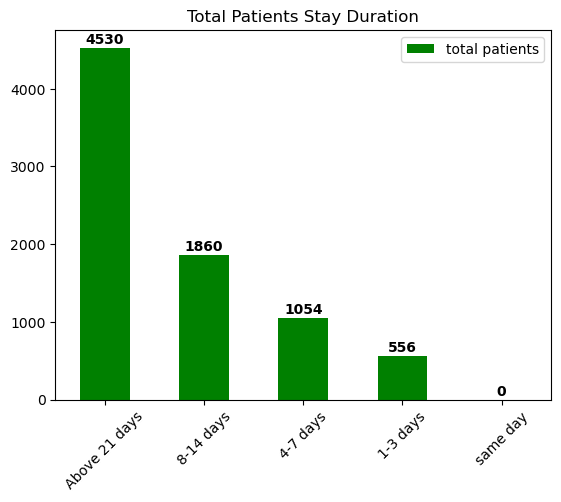

In [43]:
# creating a visual for it 
ax=total_group_patients.plot(kind='bar',color='green')
ax.bar_label(ax.containers[0], padding=1, fontsize=10, fontweight='bold')
plt.xticks(range(len(total_group_patients)),total_group_patients['Stay Bucket'],rotation=45)
plt.title('Total Patients Stay Duration')
plt.show()

# 9 for any records with a recorded course of death analyse pattern to identify risk factor

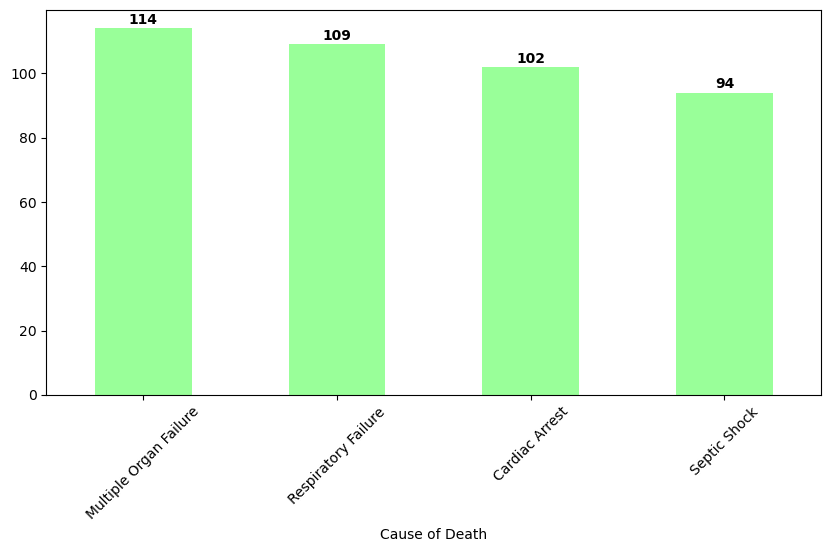

In [25]:
death_cause=df.dropna(subset='Cause of Death')

count_cause=death_cause['Cause of Death'].value_counts()
#death_cause.head()
plt.figure(figsize=(10,5))
ax=count_cause.plot(kind='bar',color='#99ff99')
ax.bar_label(ax.containers[0], padding=1, fontsize=10, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# 10 what are the percentage of the following patients Deceased, Under- treatment and Recovered Patients?

In [26]:
#total patients
total_patients=df.shape[0]

#total deceased patients
Deceased_patients=(df['Treatment Status']=='Deceased').sum()
#pct Deceased_patients
Deceased_rate=format((Deceased_patients/total_patients)*100,".2f") 

#total Under-treatment patients
Under_treatment=(df['Treatment Status']=='Under Treatment').sum()
#pct Under_treatment patients
Under_treatment_rate=format((Under_treatment/total_patients)*100,".2f")

#total Recovered patients
Recovered_patients=(df['Treatment Status']=='Recovered').sum()
#pct Recovered patients
Recovered_rate=format((Recovered_patients/total_patients)*100,".2f")

print(f"{Recovered_rate:}%")

85.24%


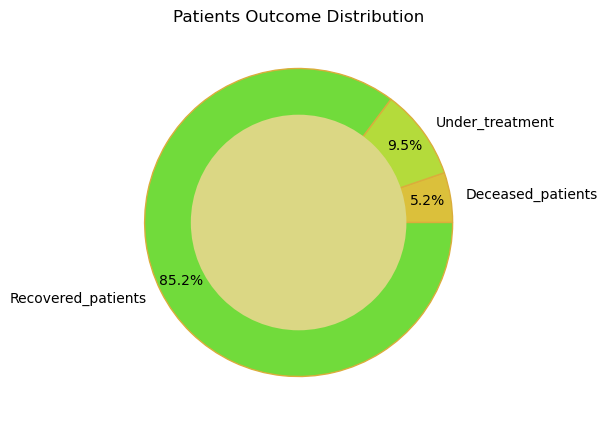

In [27]:
size=[Deceased_rate,Under_treatment_rate,Recovered_rate]
labels=['Deceased_patients','Under_treatment','Recovered_patients']
plt.figure(figsize=(8,5))
plt.pie(size,labels=labels,autopct='%1.1f%%',
       colors=['#DBC03B','#B4DB3B','#71DB3B'],
       wedgeprops={'width': 0.4, 'edgecolor': '#DBAD3B'},
       pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.70, fc='#DBD784')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Patients Outcome Distribution')
plt.show()

# 10 what are the peak day of the week in a month bases for admission and discharge

In [28]:
df.info()
#both discharge and admission date are already on datatime format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Patient ID        8000 non-null   object        
 1   Gender            8000 non-null   object        
 2   Disease           8000 non-null   object        
 3   Treatment         8000 non-null   object        
 4   Hospital          8000 non-null   object        
 5   Admission Date    8000 non-null   datetime64[ns]
 6   Discharge Date    8000 non-null   datetime64[ns]
 7   Treatment Status  8000 non-null   object        
 8   Cause of Death    419 non-null    object        
 9   Date of Birth     8000 non-null   datetime64[ns]
 10  Age               8000 non-null   int64         
 11  Age Group         7970 non-null   category      
 12  Stay Duration     8000 non-null   int64         
 13  Stay Bucket       8000 non-null   category      
dtypes: category(2), datetime

In [29]:
# extracting the month from the admission date. creating a new column for it 
df['Admission Month']=df['Admission Date'].dt.strftime('%b')
df['Admission Day']=df['Admission Date'].dt.strftime('%a')

month_count_patients=df['Admission Month'].value_counts() 
day_count_patients=df['Admission Day'].value_counts()

print(month_count_patients,day_count_patients)
# now both the days and the months are notin order we need to create a variable to store ordered days and months

Admission Month
Jan    1000
May     671
Aug     666
Sep     658
Oct     641
Mar     640
Jul     639
Dec     630
Apr     625
Jun     617
Nov     616
Feb     597
Name: count, dtype: int64 Admission Day
Sun    1179
Fri    1177
Wed    1167
Thu    1151
Sat    1143
Mon    1096
Tue    1087
Name: count, dtype: int64


In [30]:
#creating variable to store ordered days and months
ordered_month=['Jan','Feb','Mar','Apr','May','Jun',
             'Jul','Aug','Sep','Oct','Nov','Dec']

ordered_days=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# creating a pivot table 
admission_heatmap=df.pivot_table(index='Admission Day',columns='Admission Month',aggfunc='size',fill_value=0)
admission_heatmap
# the day and months are not in order we need to address this 

Admission Month,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
Admission Day,,,,,,,,,,,,
Fri,93,80,103,94,150,85,99,99,80,96,81,117
Mon,84,91,90,83,145,89,77,78,98,99,86,76
Sat,86,95,112,85,147,118,73,88,89,71,82,97
Sun,90,95,97,98,157,98,92,72,101,74,119,86
Thu,80,105,90,72,133,79,108,103,95,95,83,108
Tue,89,106,63,76,140,62,87,79,114,78,105,88
Wed,103,94,75,89,128,108,81,121,94,103,85,86


In [31]:
admission_heatmap_sorted=admission_heatmap.reindex(index=ordered_days,columns=ordered_month,fill_value=0)
admission_heatmap_sorted

Admission Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Admission Day,,,,,,,,,,,,
Mon,145,83,78,84,98,77,89,91,76,86,99,90
Tue,140,76,79,89,114,87,62,106,88,105,78,63
Wed,128,89,121,103,94,81,108,94,86,85,103,75
Thu,133,72,103,80,95,108,79,105,108,83,95,90
Fri,150,94,99,93,80,99,85,80,117,81,96,103
Sat,147,85,88,86,89,73,118,95,97,82,71,112
Sun,157,98,72,90,101,92,98,95,86,119,74,97


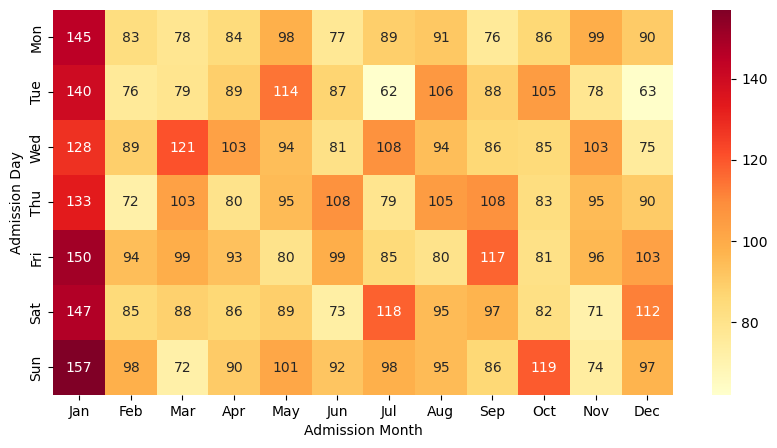

In [32]:
#to plot the heat map 
plt.figure(figsize=(10,5))
sns.heatmap(admission_heatmap_sorted,annot=True,fmt='d',cmap='YlOrRd')
plt.show()

# 11 what is the no of patients admmitd per week, month and Year. Add a filter to filter the month by year

In [33]:
admission_day=df.groupby('Admission Day').size()
admission_day=admission_day.reindex(ordered_days,fill_value=0)
admission_day

Admission Day
Mon    1096
Tue    1087
Wed    1167
Thu    1151
Fri    1177
Sat    1143
Sun    1179
dtype: int64

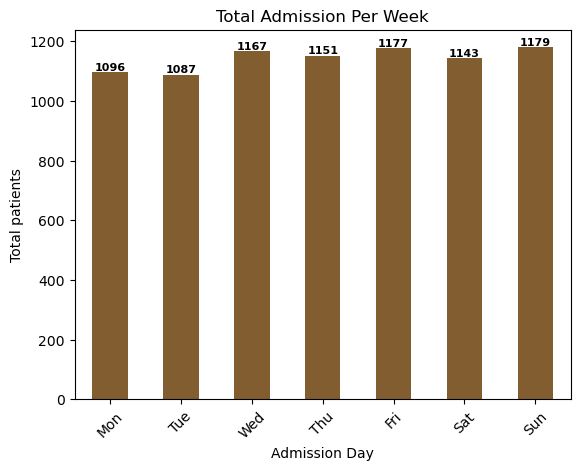

In [34]:
ax=admission_day.plot(kind='bar',color='#815D30')
ax.bar_label(ax.containers[0],padding=0, fontsize=8,fontweight='bold')
plt.xticks(rotation=45)
plt.title('Total Admission Per Week') 
plt.ylabel('Total patients')
plt.show()

# Adding month filter to the weekly addmision rate

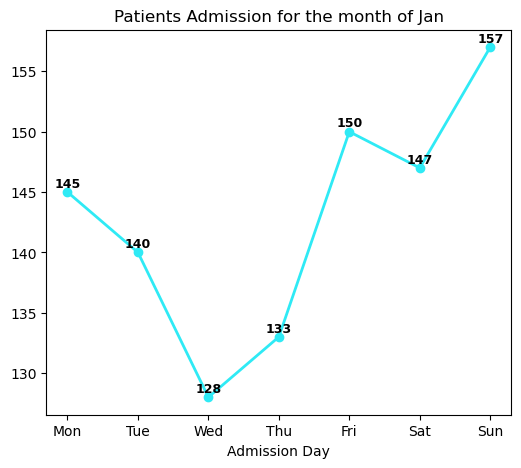

In [35]:
# the month filter
selected_month ='Jan'
df_Month=df[df['Admission Date'].dt.strftime('%b')==selected_month].copy()
weekly_admission=df_Month.groupby('Admission Day').size().reindex(ordered_days)
#plotting the visual
plt.figure(figsize=(6, 5))
ax = weekly_admission.plot(kind='line', color='#2FEAF5', marker='o', linewidth=2)

# 2. ADD LABELS MANUALLY (Since line charts don't have containers)
for i, val in enumerate(weekly_admission):
    ax.text(i, val + 0.4, str(val), horizontalalignment='center', 
            fontsize=9, fontweight='bold', color='black')
plt.title(f'Patients Admission for the month of {selected_month}')
plt.show()

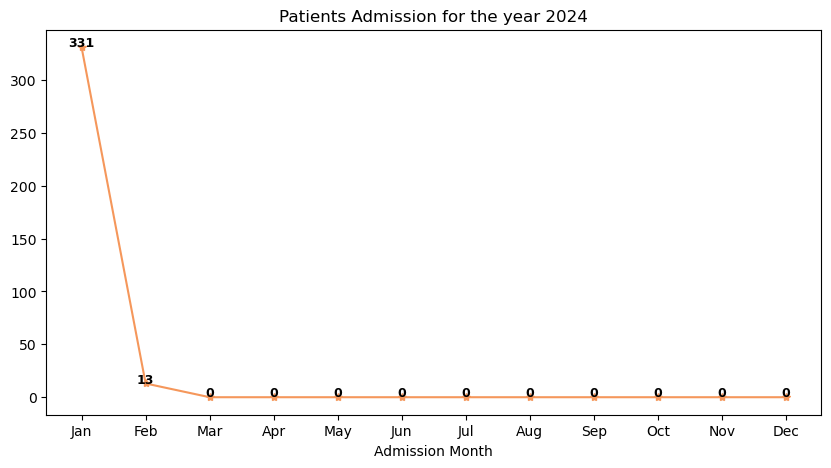

In [36]:
selectec_year=2024
df_year=df[df['Admission Date'].dt.year==selectec_year].copy()
monthly_admission=df_year.groupby('Admission Month').size().reindex(ordered_month,fill_value=0)
#plotting the visual
plt.figure(figsize=(10,5))
ax=monthly_admission.plot(kind='line',color='#F5975B',marker='*')

# 2. ADD LABELS MANUALLY (Since line charts don't have containers)
for i, val in enumerate(monthly_admission):
    ax.text(i, val + 0.4, str(val), horizontalalignment='center', 
            fontsize=9, fontweight='bold', color='black')
plt.title(f'Patients Admission for the year {selectec_year}')
plt.xticks(range(len(monthly_admission)), monthly_admission.index)
plt.show()
